<a href="https://colab.research.google.com/github/ghfreiree/fitness-data-insights/blob/main/gym_athletes_data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Objetivo: descobrir quais são os principais fatores que diminuem o BF (índice de gordura) dos atletas de academia

## Conhecendo os dados

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

path = '/content/gym_members_exercise_tracking.csv'

df = pd.read_csv(path)
df.head()

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 973 entries, 0 to 972
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            973 non-null    int64  
 1   Gender                         973 non-null    object 
 2   Weight (kg)                    973 non-null    float64
 3   Height (m)                     973 non-null    float64
 4   Max_BPM                        973 non-null    int64  
 5   Avg_BPM                        973 non-null    int64  
 6   Resting_BPM                    973 non-null    int64  
 7   Session_Duration (hours)       973 non-null    float64
 8   Calories_Burned                973 non-null    float64
 9   Workout_Type                   973 non-null    object 
 10  Fat_Percentage                 973 non-null    float64
 11  Water_Intake (liters)          973 non-null    float64
 12  Workout_Frequency (days/week)  973 non-null    int

In [ ]:
df['Workout_Type'].unique()

array(['Yoga', 'HIIT', 'Cardio', 'Strength'], dtype=object)

In [ ]:
df['Workout_Frequency (days/week)'].unique()

array([4, 3, 5, 2])

In [ ]:
df['Session_Duration (hours)'].sort_values().unique()

array([0.5 , 0.51, 0.52, 0.53, 0.54, 0.55, 0.56, 0.57, 0.58, 0.59, 0.6 ,
       0.61, 0.62, 0.63, 0.64, 0.66, 0.67, 0.68, 0.69, 0.7 , 0.71, 0.72,
       0.73, 0.74, 0.75, 0.76, 0.77, 0.78, 0.79, 0.8 , 0.81, 0.82, 0.83,
       0.84, 0.85, 0.86, 0.87, 0.88, 0.89, 0.9 , 0.91, 0.92, 0.93, 0.94,
       0.95, 0.96, 0.97, 0.99, 1.  , 1.01, 1.02, 1.03, 1.04, 1.05, 1.06,
       1.07, 1.08, 1.09, 1.1 , 1.11, 1.12, 1.13, 1.14, 1.15, 1.16, 1.17,
       1.18, 1.19, 1.2 , 1.21, 1.22, 1.23, 1.24, 1.25, 1.26, 1.27, 1.28,
       1.29, 1.3 , 1.31, 1.32, 1.33, 1.34, 1.35, 1.36, 1.37, 1.38, 1.39,
       1.4 , 1.41, 1.42, 1.43, 1.44, 1.45, 1.46, 1.47, 1.48, 1.49, 1.5 ,
       1.51, 1.52, 1.53, 1.54, 1.55, 1.56, 1.57, 1.58, 1.59, 1.6 , 1.61,
       1.62, 1.63, 1.64, 1.65, 1.66, 1.67, 1.68, 1.69, 1.7 , 1.71, 1.72,
       1.73, 1.74, 1.75, 1.76, 1.77, 1.78, 1.79, 1.8 , 1.81, 1.82, 1.83,
       1.84, 1.85, 1.86, 1.87, 1.88, 1.9 , 1.91, 1.93, 1.94, 1.95, 1.96,
       1.97, 1.98, 1.99, 2.  ])

## Hipótese 1: Tipo de treino ❌

In [ ]:
df_cardio = df[df['Workout_Type'] == 'Cardio'].copy()

df_hiit = df[df['Workout_Type'] == 'HIIT'].copy()

df_strength = df[df['Workout_Type'] == 'Strength'].copy()

df_yoga = df[df['Workout_Type'] == 'Yoga'].copy()

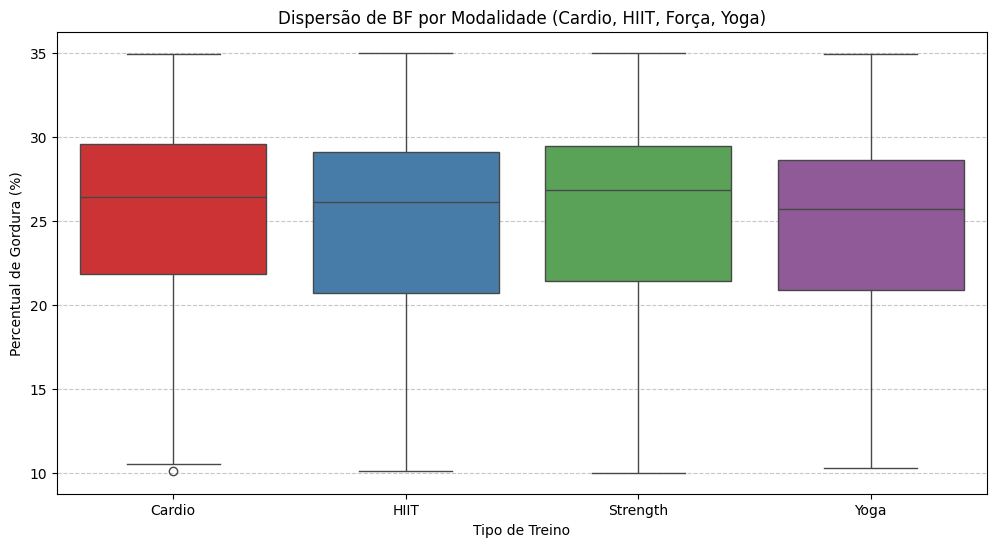

In [ ]:
df_comp_geral = pd.concat([df_cardio, df_hiit, df_strength, df_yoga])

plt.figure(figsize=(12, 6))
sns.boxplot(x='Workout_Type', y='Fat_Percentage', data=df_comp_geral,
            hue='Workout_Type', palette='Set1', legend=False)

plt.title('Dispersão de BF por Modalidade (Cardio, HIIT, Força, Yoga)')
plt.xlabel('Tipo de Treino')
plt.ylabel('Percentual de Gordura (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

**HIPÓTESE REFUTADA** ❌

## Hipótese 2: Duração do treino ✅


In [ ]:
df['Session_Duration (hours)'].sort_values().unique()

array([0.5 , 0.51, 0.52, 0.53, 0.54, 0.55, 0.56, 0.57, 0.58, 0.59, 0.6 ,
       0.61, 0.62, 0.63, 0.64, 0.66, 0.67, 0.68, 0.69, 0.7 , 0.71, 0.72,
       0.73, 0.74, 0.75, 0.76, 0.77, 0.78, 0.79, 0.8 , 0.81, 0.82, 0.83,
       0.84, 0.85, 0.86, 0.87, 0.88, 0.89, 0.9 , 0.91, 0.92, 0.93, 0.94,
       0.95, 0.96, 0.97, 0.99, 1.  , 1.01, 1.02, 1.03, 1.04, 1.05, 1.06,
       1.07, 1.08, 1.09, 1.1 , 1.11, 1.12, 1.13, 1.14, 1.15, 1.16, 1.17,
       1.18, 1.19, 1.2 , 1.21, 1.22, 1.23, 1.24, 1.25, 1.26, 1.27, 1.28,
       1.29, 1.3 , 1.31, 1.32, 1.33, 1.34, 1.35, 1.36, 1.37, 1.38, 1.39,
       1.4 , 1.41, 1.42, 1.43, 1.44, 1.45, 1.46, 1.47, 1.48, 1.49, 1.5 ,
       1.51, 1.52, 1.53, 1.54, 1.55, 1.56, 1.57, 1.58, 1.59, 1.6 , 1.61,
       1.62, 1.63, 1.64, 1.65, 1.66, 1.67, 1.68, 1.69, 1.7 , 1.71, 1.72,
       1.73, 1.74, 1.75, 1.76, 1.77, 1.78, 1.79, 1.8 , 1.81, 1.82, 1.83,
       1.84, 1.85, 1.86, 1.87, 1.88, 1.9 , 1.91, 1.93, 1.94, 1.95, 1.96,
       1.97, 1.98, 1.99, 2.  ])

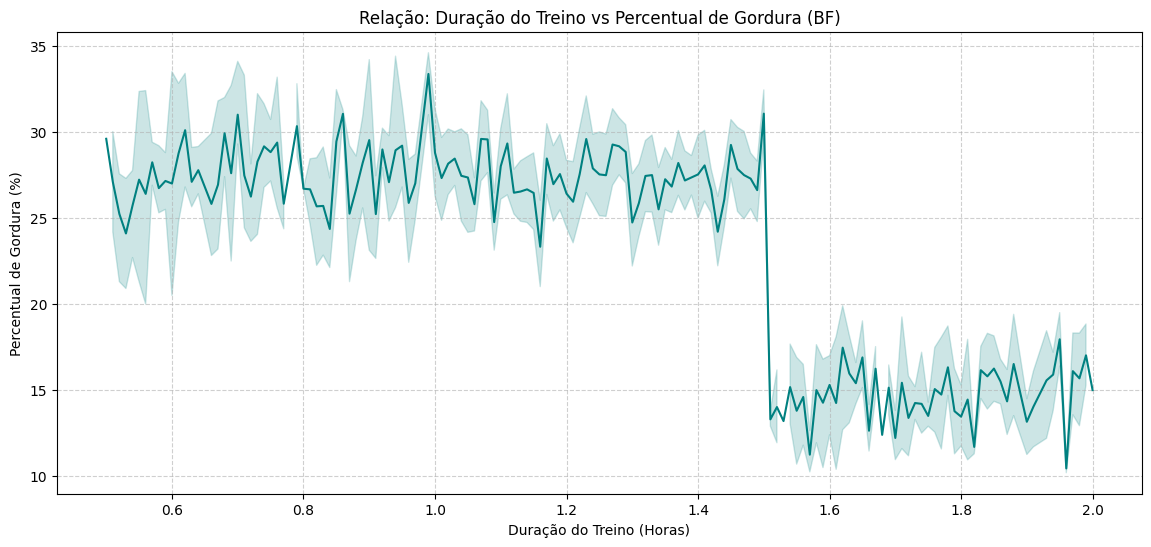

In [ ]:
plt.figure(figsize=(14, 6))
sns.lineplot(x='Session_Duration (hours)', y='Fat_Percentage', data=df, color='teal')

plt.title('Relação: Duração do Treino vs Percentual de Gordura (BF)')
plt.xlabel('Duração do Treino (Horas)')
plt.ylabel('Percentual de Gordura (%)')
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

In [ ]:
# Descobrindo o valor exato da duração do treino do grupo de atletas com BF baixo
df[df['Fat_Percentage'] < 20]['Session_Duration (hours)'].sort_values()

,Session_Duration (hours)
426,1.51
673,1.51
759,1.51
34,1.52
396,1.52
...,...
66,1.99
943,1.99
848,1.99
964,1.99


O gráfico diz uma informação muito importante: as pessoas que treinam por mais de ~1h30m, tem **visivelmente** menos BF que as outras. Para ter uma análise mais profunda, vamos dividir esses grupos.

## Investigando os grupos

In [ ]:
# Separando os atletas pelo nível de BF
df_menor_bf = df[df['Session_Duration (hours)'] > 1.5]
df_maior_bf = df[df['Session_Duration (hours)'] <= 1.5]

In [ ]:
df_menor_bf.shape

(191, 15)

In [ ]:
df_maior_bf.shape

(782, 15)

In [ ]:
# Porcentagem de pessoas que treinam mais de 1h30m

191/(191+782)

0.1963001027749229

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 973 entries, 0 to 972
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            973 non-null    int64  
 1   Gender                         973 non-null    object 
 2   Weight (kg)                    973 non-null    float64
 3   Height (m)                     973 non-null    float64
 4   Max_BPM                        973 non-null    int64  
 5   Avg_BPM                        973 non-null    int64  
 6   Resting_BPM                    973 non-null    int64  
 7   Session_Duration (hours)       973 non-null    float64
 8   Calories_Burned                973 non-null    float64
 9   Workout_Type                   973 non-null    object 
 10  Fat_Percentage                 973 non-null    float64
 11  Water_Intake (liters)          973 non-null    float64
 12  Workout_Frequency (days/week)  973 non-null    int

Agora vamos tentar identificar outras diferenças entre os grupos

In [ ]:
# Tipo de treino
df_menor_bf['Workout_Type'].value_counts(normalize=True)

,proportion
Workout_Type,
Yoga,0.277487
HIIT,0.256545
Strength,0.235602
Cardio,0.230366


In [ ]:
df_maior_bf['Workout_Type'].value_counts(normalize=True)

,proportion
Workout_Type,
Strength,0.272379
Cardio,0.269821
Yoga,0.237852
HIIT,0.219949


O tipo de treino não demonstrou ter influência alguma entre os grupos

In [ ]:
# Ingestão de água
df_menor_bf['Water_Intake (liters)'].describe()

,Water_Intake (liters)
count,191.000000
mean,3.123037
std,0.400386
min,2.700000
25%,2.700000
50%,3.500000
75%,3.500000
max,3.500000


In [ ]:
df_maior_bf['Water_Intake (liters)'].describe()

,Water_Intake (liters)
count,782.000000
mean,2.505371
std,0.578197
min,1.500000
25%,2.100000
50%,2.400000
75%,2.900000
max,3.700000


Ainda que há uma diferença na ingestão de água entre os grupos, ela não influencia na diminuição/aumento de bf nas pessoas **pois a diferença é deprezível em proporção a mudança no BF**.

In [ ]:
# Frequência de treino
df_menor_bf['Workout_Frequency (days/week)'].value_counts(normalize=True)

,proportion
Workout_Frequency (days/week),
5,0.534031
4,0.465969


In [ ]:
df_maior_bf['Workout_Frequency (days/week)'].value_counts(normalize=True)

,proportion
Workout_Frequency (days/week),
3,0.470588
4,0.277494
2,0.251918


Percebe-se uma grande diferença na frequência de treino dos dois grupos, evidenciando uma relação direta entre BF e frequência de treino dos atletas. Vamos visualizar essa relação

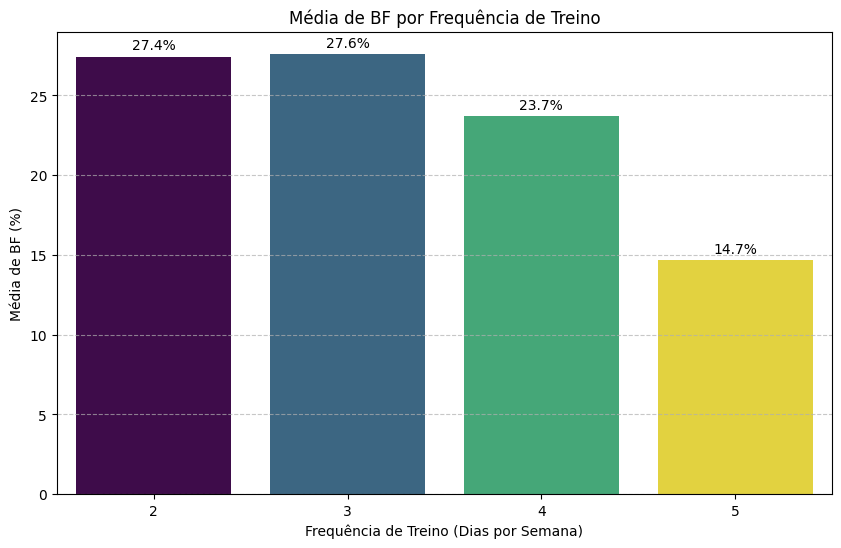

In [ ]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Workout_Frequency (days/week)', y='Fat_Percentage', data=df, hue='Workout_Frequency (days/week)', palette='viridis', errorbar=None, legend=False)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

plt.title('Média de BF por Frequência de Treino')
plt.xlabel('Frequência de Treino (Dias por Semana)')
plt.ylabel('Média de BF (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

A partir dessa análise é possível dizer que a frequência de treino também é um dos fatores principais que influenciam no aumento/queda do BF das pessoas.

In [ ]:
# Continuando a análise dos grupos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 973 entries, 0 to 972
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            973 non-null    int64  
 1   Gender                         973 non-null    object 
 2   Weight (kg)                    973 non-null    float64
 3   Height (m)                     973 non-null    float64
 4   Max_BPM                        973 non-null    int64  
 5   Avg_BPM                        973 non-null    int64  
 6   Resting_BPM                    973 non-null    int64  
 7   Session_Duration (hours)       973 non-null    float64
 8   Calories_Burned                973 non-null    float64
 9   Workout_Type                   973 non-null    object 
 10  Fat_Percentage                 973 non-null    float64
 11  Water_Intake (liters)          973 non-null    float64
 12  Workout_Frequency (days/week)  973 non-null    int

In [ ]:
# Gênero
df_menor_bf['Gender'].value_counts(normalize=True)

,proportion
Gender,
Male,0.528796
Female,0.471204


In [ ]:
df_maior_bf['Gender'].value_counts(normalize=True)

,proportion
Gender,
Male,0.524297
Female,0.475703


O gênero também não demonstra efeito nenhum no BF dos atletas, informação que contraria as crenças populares.

In [ ]:
# Idade
df_menor_bf['Age'].describe()

,Age
count,191.000000
mean,38.287958
std,11.783834
min,18.000000
25%,29.000000
50%,39.000000
75%,48.000000
max,59.000000


In [ ]:
df_maior_bf['Age'].describe()

,Age
count,782.000000
mean,38.780051
std,12.281388
min,18.000000
25%,28.000000
50%,40.000000
75%,50.000000
max,59.000000


Idade também não influencia no bf dos atletas, informação que também pode surpreender

In [ ]:
# Nível de experiência
df_menor_bf['Experience_Level'].value_counts(normalize=True)

,proportion
Experience_Level,
3,1.0


In [ ]:
df_maior_bf['Experience_Level'].value_counts(normalize=True)

,proportion
Experience_Level,
2,0.519182
1,0.480818


Aqui descobrimos que o grupo dos atletas com BF baixo é representado por atletas experientes.

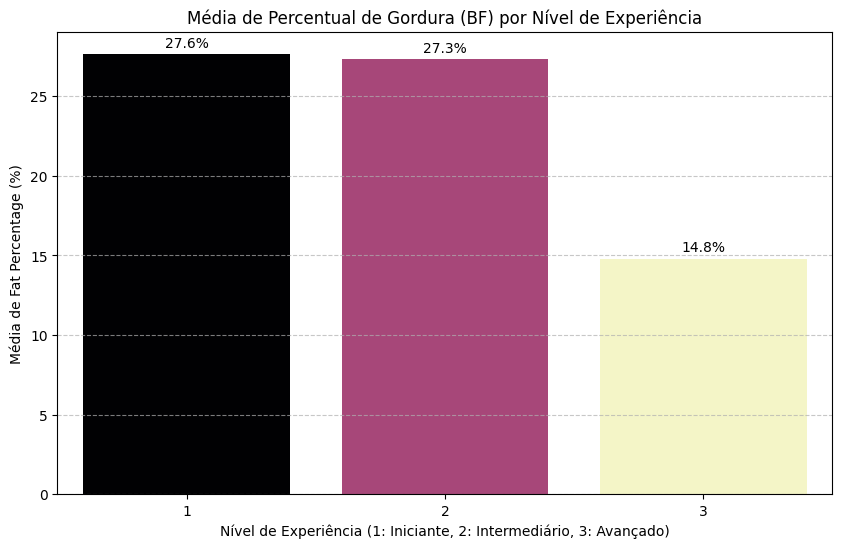

In [ ]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Experience_Level', y='Fat_Percentage', data=df, hue='Experience_Level', palette='magma', errorbar=None, legend=False)

# Adicionando os rótulos de dados
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

plt.title('Média de Percentual de Gordura (BF) por Nível de Experiência')
plt.xlabel('Nível de Experiência (1: Iniciante, 2: Intermediário, 3: Avançado)')
plt.ylabel('Média de Fat Percentage (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

Nesse gráfico fica claro a diferença entre o nível 3 e os outros níveis de experiência com uma diferença de **cerca de 13%** na média de BF.

In [ ]:
# Análise do BF nos atletas experientes
df[df['Experience_Level'] == 3]['Fat_Percentage'].describe()

,Fat_Percentage
count,191.000000
mean,14.790576
std,2.950649
min,10.000000
25%,12.150000
50%,14.600000
75%,17.300000
max,20.000000


In [ ]:
# Análise da frequência de treino dos atletas experientes
df[df['Experience_Level'] == 3]['Workout_Frequency (days/week)'].value_counts(normalize=True)

,proportion
Workout_Frequency (days/week),
5,0.534031
4,0.465969


## Resumo

### Duração do Treino

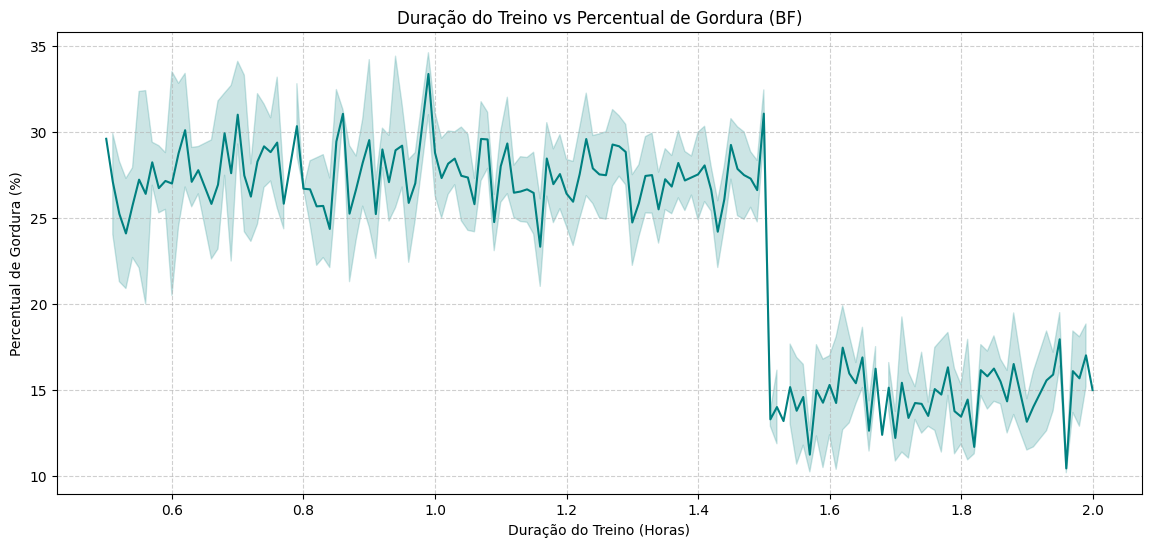

In [ ]:
plt.figure(figsize=(14, 6))
sns.lineplot(x='Session_Duration (hours)', y='Fat_Percentage', data=df, color='teal')

plt.title('Duração do Treino vs Percentual de Gordura (BF)')
plt.xlabel('Duração do Treino (Horas)')
plt.ylabel('Percentual de Gordura (%)')
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

A partir do gráfico foi possível dividir as pessoas em dois grupos com níveis de BF bem distintos:
- Pessoas que os treinos duravam até 1h30m (BF's mais altos)
- Pessoas que os treinos duravam entre 1h30m e 2h (BF's mais baixos)

Sem uma análise mais aprofundada desses grupos, os dados de duração do treino poderiam ser **mal interpretados**, podendo ser confundidos com a **causa** da diminuição do BF das pessoas.

### Frequência de Treino

Após a separação dos grupos, os primeiros dados que apresentaram grande distinção entre os grupos foi a **frenquência de treino**. Uma observação importante sobre esses dados foi que o **grupo com maior BF** tinham apenas atletas que treinavam **de 2 a 4 vezes na semana**, com a maioria treinando apenas 3 vezes. Já no grupo que possuía **menor BF**, os atletas treinavam **4 ou 5 vezes na semana**, dessa vez sendo distribuídos de forma praticamente igual entre as frequências.

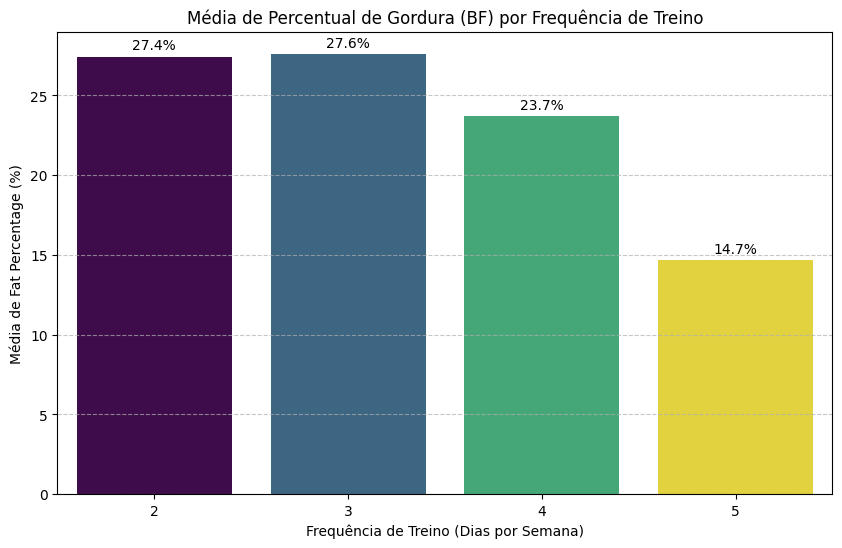

In [ ]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Workout_Frequency (days/week)', y='Fat_Percentage', data=df, hue='Workout_Frequency (days/week)', palette='viridis', errorbar=None, legend=False)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

plt.title('Média de Percentual de Gordura (BF) por Frequência de Treino')
plt.xlabel('Frequência de Treino (Dias por Semana)')
plt.ylabel('Média de Fat Percentage (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

No gráfico, fica explícita a diferença da média de BF entre pessoas que treinam mais de 3x/semana com o resto, sendo em média **3.9% para quem treina 4x/semana e 12.9% para quem treina 5x/semana.**

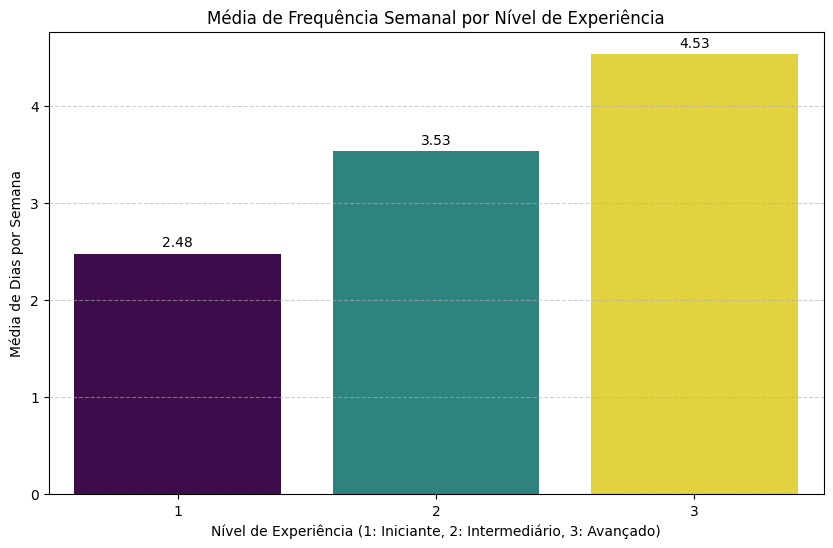

In [ ]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Experience_Level', y='Workout_Frequency (days/week)', data=df, hue='Experience_Level', palette='viridis', errorbar=None, legend=False)

# Adicionando os rótulos com a média exata
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)

plt.title('Média de Frequência Semanal por Nível de Experiência')
plt.xlabel('Nível de Experiência (1: Iniciante, 2: Intermediário, 3: Avançado)')
plt.ylabel('Média de Dias por Semana')
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

Agora com essse gráfico, fica clara a **relação entre experiência e frequência de treino na academia**. Pode-se dizer que eles são proporcionais.

### Nível de Experiência

Esse dado se mostrou ser decisivo para saber se alguém tem um nível de BF baixo ou não. Nessa base de dados **100% das pessoas que tem nível 3 de experiência têm um BF menor**.

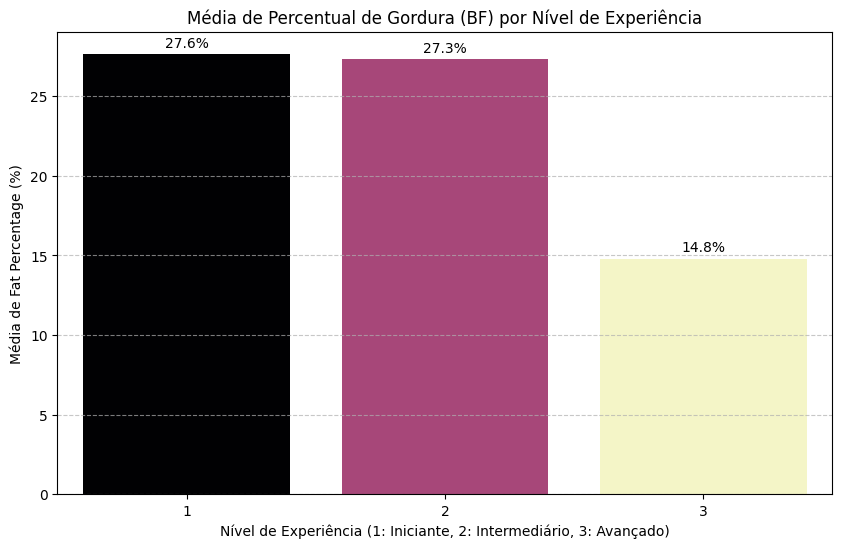

In [ ]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Experience_Level', y='Fat_Percentage', data=df, hue='Experience_Level', palette='magma', errorbar=None, legend=False)

# Adicionando os rótulos de dados
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

plt.title('Média de Percentual de Gordura (BF) por Nível de Experiência')
plt.xlabel('Nível de Experiência (1: Iniciante, 2: Intermediário, 3: Avançado)')
plt.ylabel('Média de Fat Percentage (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

No gráfico é possível visualizar uma **diferença de 12.5% na média de BF entre níveis experientes e intermediários na academia**. Além disso, o valor do BF das pessoas nesses níveis é praticamente igual ao valor em pessoas que treinam 3 e 5 vezes na semana. Ou seja, esses dados registraram que a **diferença de BF entre um intermediário e um experiente é praticamente igual a
diferença entre alguém que treina 3 e 5 vezes na semana**.

## Conclusão

Em conclusão, se você quer maximizar suas chances de ter um BF baixo, você precisa focar em se tornar um experiente na academia, pois **todos os atletas experientes apresentaram níveis baixo de BF**, independente de sexo, idade, etc. Além disso, você pode tentar aderir aos hábitos de treinar 5 vezes na semana e realizar treinos de no mínimo 1h30m, pois 100% dos atletas com esses dois hábitos também têm BF baixo.